In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the Netflix dataset
df = pd.read_csv("netflix_titles.csv")

# Display the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
# Remove duplicate records
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8807, 12)


In [8]:
# Statistical summary of numerical columns

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
# Visualize the distribution of Movies and TV Shows

plt.figure(figsize=(7, 5))

type_counts.plot(kind='bar')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.show()

NameError: name 'type_counts' is not defined

<Figure size 700x500 with 0 Axes>

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


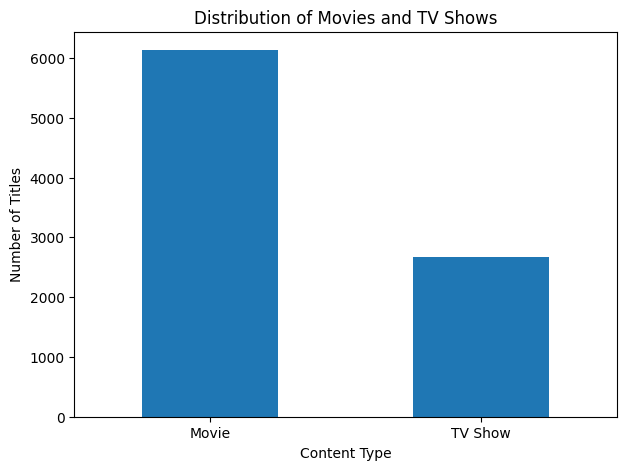

In [10]:
# Movies vs TV Shows

type_counts = df['type'].value_counts()

print(type_counts)

plt.figure(figsize=(7, 5))
type_counts.plot(kind='bar')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.show()

In [11]:
# Analyze content ratings

rating_counts = df['rating'].value_counts()

print("Content Ratings:")
print(rating_counts)

Content Ratings:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


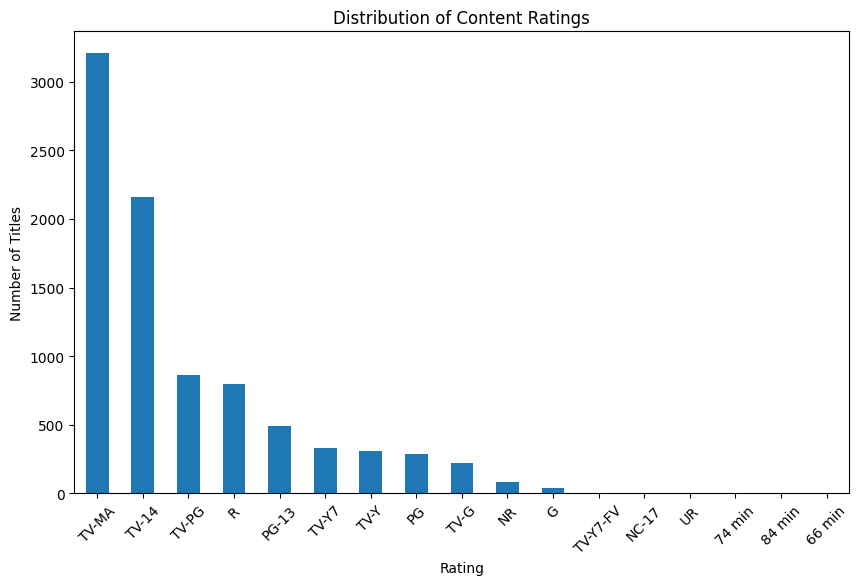

In [12]:
# Visualize content ratings

plt.figure(figsize=(10, 6))

rating_counts.plot(kind='bar')

plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

In [13]:
# Analyze titles by release year

release_year_counts = df['release_year'].value_counts().sort_index()

print("Number of titles by release year:")
print(release_year_counts.tail(20))

Number of titles by release year:
release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


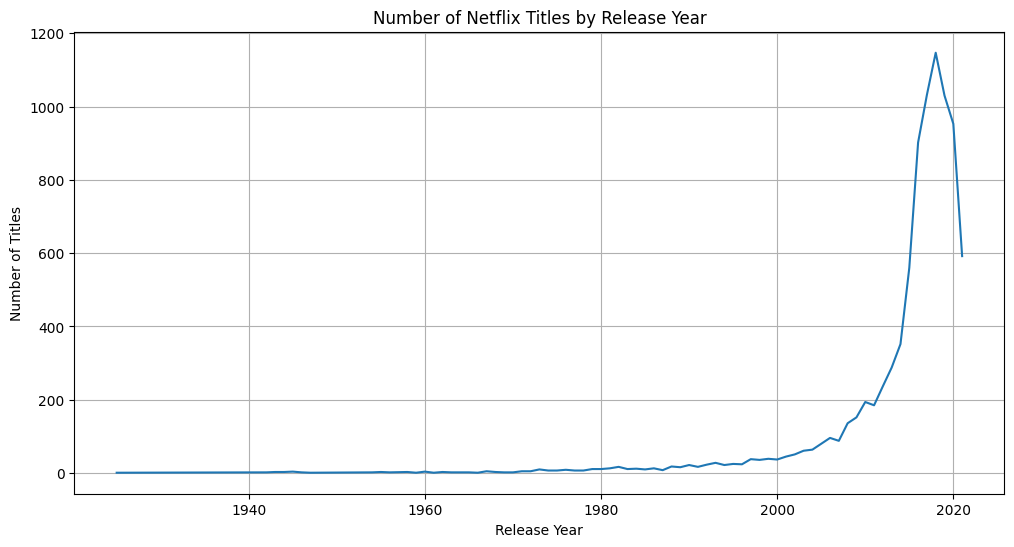

In [14]:
# Visualize titles by release year

plt.figure(figsize=(12, 6))

release_year_counts.plot(kind='line')

plt.title('Number of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

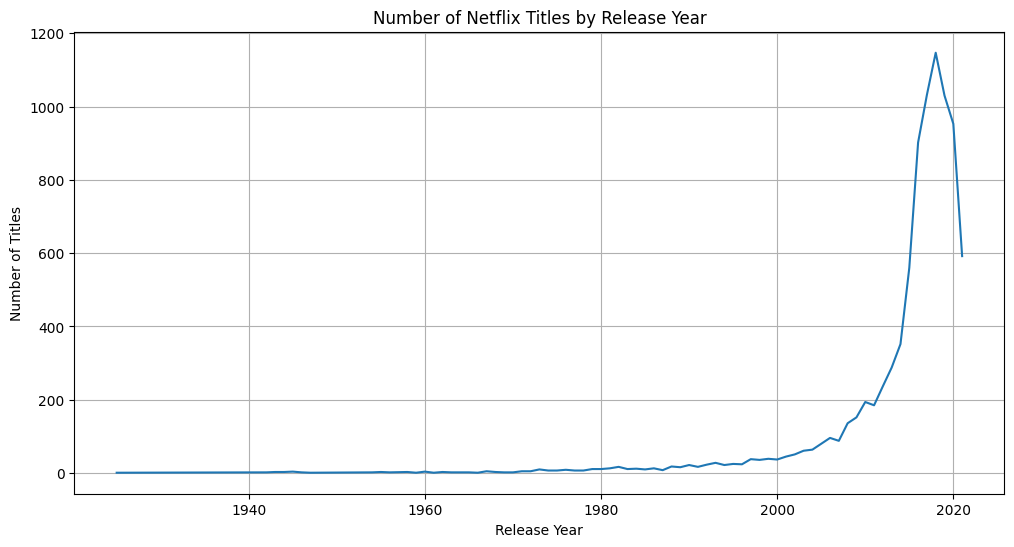

In [15]:
# Visualize titles by release year

plt.figure(figsize=(12, 6))

release_year_counts.plot(kind='line')

plt.title('Number of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

In [16]:
# Extract numeric duration values

df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)

# Extract duration unit
df['duration_unit'] = df['duration'].str.extract('([A-Za-z]+)')

print(df[['type', 'title', 'duration', 'duration_value', 'duration_unit']].head(10))

      type                             title   duration  duration_value  \
0    Movie              Dick Johnson Is Dead     90 min            90.0   
1  TV Show                     Blood & Water  2 Seasons             2.0   
2  TV Show                         Ganglands   1 Season             1.0   
3  TV Show             Jailbirds New Orleans   1 Season             1.0   
4  TV Show                      Kota Factory  2 Seasons             2.0   
5  TV Show                     Midnight Mass   1 Season             1.0   
6    Movie  My Little Pony: A New Generation     91 min            91.0   
7    Movie                           Sankofa    125 min           125.0   
8  TV Show     The Great British Baking Show  9 Seasons             9.0   
9    Movie                      The Starling    104 min           104.0   

  duration_unit  
0           min  
1       Seasons  
2        Season  
3        Season  
4       Seasons  
5        Season  
6           min  
7           min  
8       Seas

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_922/3657637390.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)


In [17]:
# Analyze movie duration

movie_duration = df[df['type'] == 'Movie']['duration_value'].dropna()

print("Movie Duration Statistics:")
print(movie_duration.describe())

Movie Duration Statistics:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64


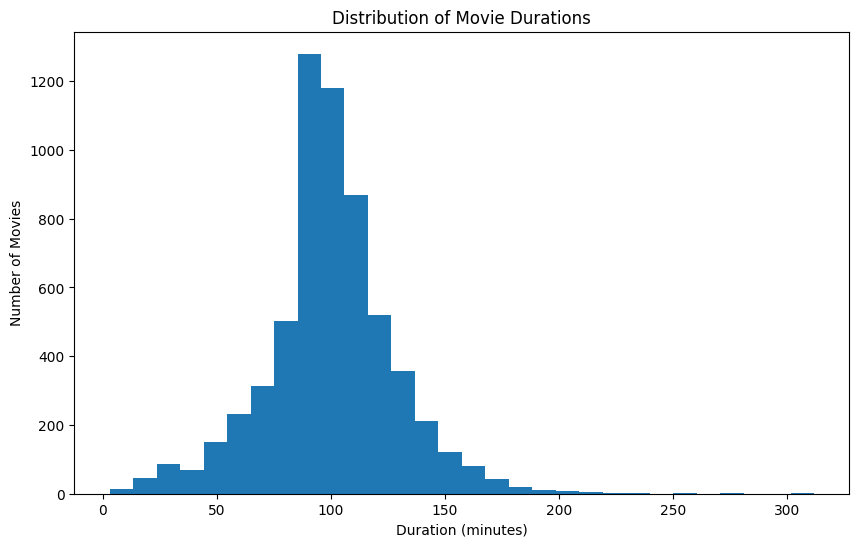

In [18]:
# Visualize movie duration

plt.figure(figsize=(10, 6))

plt.hist(movie_duration, bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

In [19]:
# Analyze TV Show seasons

tv_seasons = df[df['type'] == 'TV Show']['duration_value'].dropna()

print("TV Show Seasons Statistics:")
print(tv_seasons.describe())

TV Show Seasons Statistics:
count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64


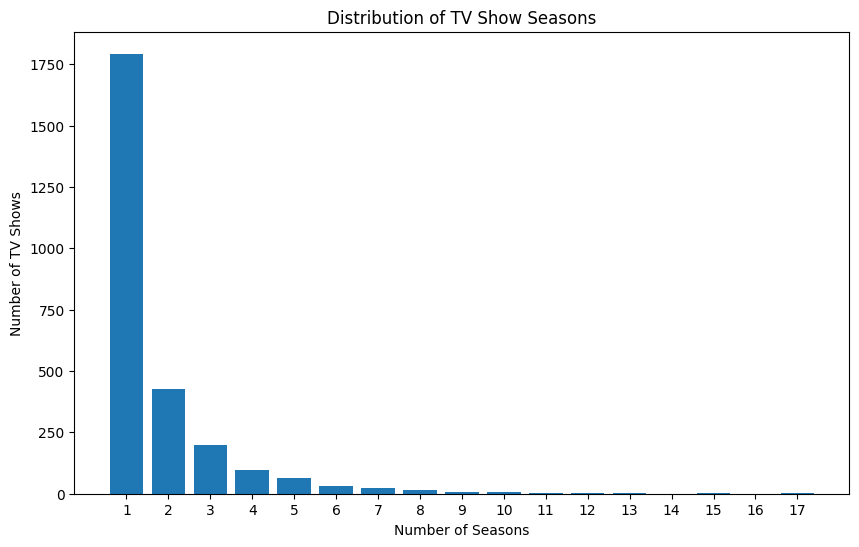

In [20]:
# Visualize the number of seasons in TV Shows

plt.figure(figsize=(10, 6))

plt.hist(tv_seasons, bins=range(1, int(tv_seasons.max()) + 2),
         align='left', rwidth=0.8)

plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(range(1, int(tv_seasons.max()) + 1))

plt.show()

In [21]:
# Analyze the countries producing the most Netflix content

country_counts = df['country'].dropna().str.split(', ').explode().value_counts()

print("Top 10 Countries by Number of Titles:")
print(country_counts.head(10))

Top 10 Countries by Number of Titles:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


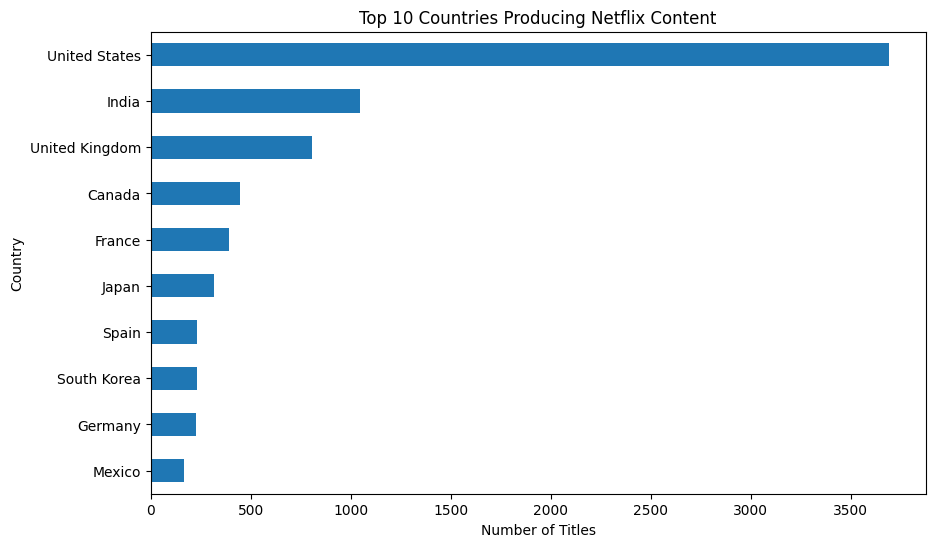

In [22]:
# Visualize the top 10 countries producing Netflix content

top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

In [23]:
# Convert date_added to datetime format

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print(df[['title', 'date_added']].head(10))

                              title date_added
0              Dick Johnson Is Dead 2021-09-25
1                     Blood & Water 2021-09-24
2                         Ganglands 2021-09-24
3             Jailbirds New Orleans 2021-09-24
4                      Kota Factory 2021-09-24
5                     Midnight Mass 2021-09-24
6  My Little Pony: A New Generation 2021-09-24
7                           Sankofa 2021-09-24
8     The Great British Baking Show 2021-09-24
9                      The Starling 2021-09-24


In [24]:
# Analyze the number of titles added to Netflix each year

df['date_added_year'] = df['date_added'].dt.year

titles_added_year = df['date_added_year'].value_counts().sort_index()

print("Titles Added to Netflix by Year:")
print(titles_added_year)

Titles Added to Netflix by Year:
date_added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


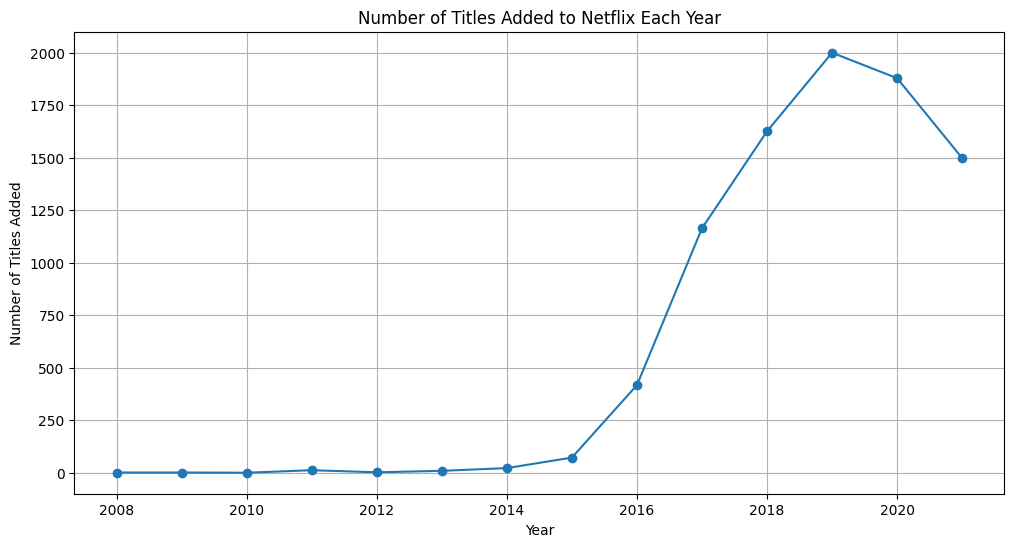

In [25]:
# Visualize Netflix titles added over the years

plt.figure(figsize=(12, 6))

titles_added_year.plot(kind='line', marker='o')

plt.title('Number of Titles Added to Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)

plt.show()

In [26]:
# Analyze the most common genres

genre_counts = df['listed_in'].dropna().str.split(', ').explode().value_counts()

print("Top 10 Genres:")
print(genre_counts.head(10))

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


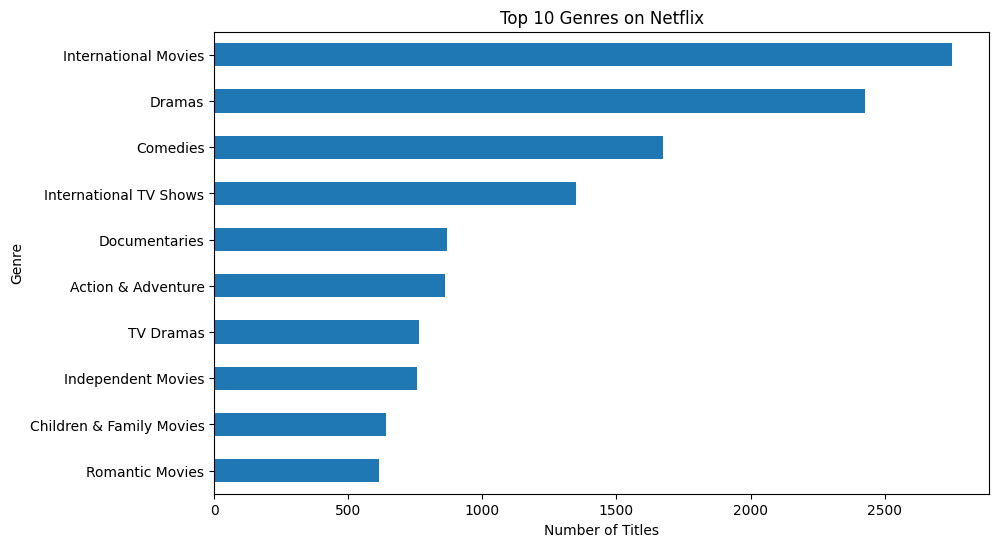

In [27]:
# Visualize the top 10 genres

top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

top_genres.sort_values().plot(kind='barh')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

In [28]:
# Analyze Movies and TV Shows by release year

type_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

print(type_year.tail(20))

type          Movie  TV Show
release_year                
2002             44        7
2003             51       10
2004             55        9
2005             67       13
2006             82       14
2007             74       14
2008            113       23
2009            118       34
2010            154       40
2011            145       40
2012            173       64
2013            225       63
2014            264       88
2015            398      162
2016            658      244
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315


<Figure size 1200x600 with 0 Axes>

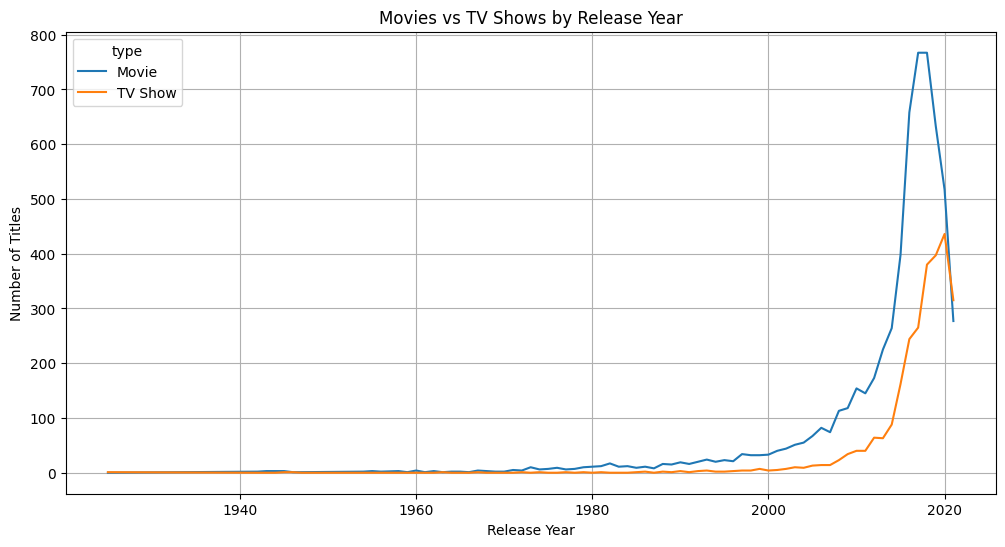

In [29]:
# Visualize Movies vs TV Shows by release year

plt.figure(figsize=(12, 6))

type_year.plot(kind='line', figsize=(12, 6))

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

In [30]:
# Key findings from the Exploratory Data Analysis

print("========== KEY FINDINGS ==========")

print("\n1. Content Type:")
print(type_counts)

print("\n2. Top 5 Ratings:")
print(rating_counts.head(5))

print("\n3. Top 5 Countries:")
print(country_counts.head(5))

print("\n4. Top 5 Genres:")
print(genre_counts.head(5))

print("\n5. Average Movie Duration:")
print(round(movie_duration.mean(), 2), "minutes")

print("\n6. Average Number of TV Show Seasons:")
print(round(tv_seasons.mean(), 2))

========== KEY FINDINGS ==========

1. Content Type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

2. Top 5 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

3. Top 5 Countries:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

4. Top 5 Genres:
listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

5. Average Movie Duration:
99.58 minutes

6. Average Number of TV Show Seasons:
1.76


In [31]:
# Save the cleaned dataset

df.to_csv("netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Movie Correlation:
                release_year  duration_value
release_year        1.000000       -0.206285
duration_value     -0.206285        1.000000

TV Show Correlation:
                release_year  duration_value
release_year        1.000000       -0.090194
duration_value     -0.090194        1.000000


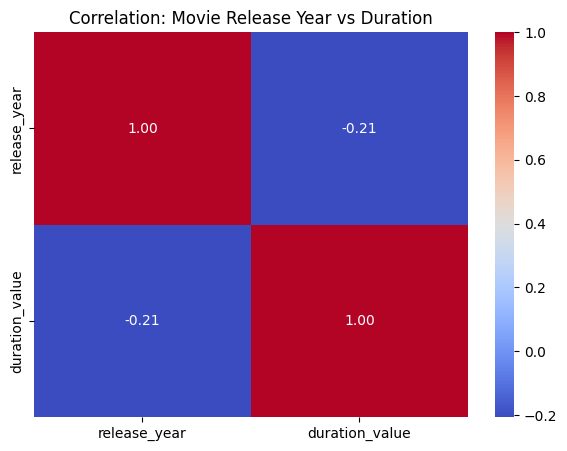

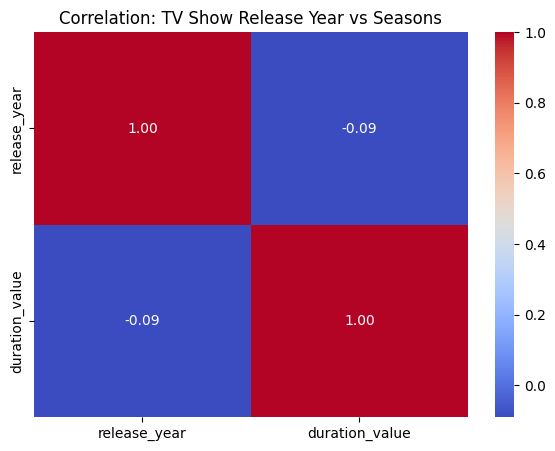

In [32]:
# Correlation Analysis

movie_corr = df[df['type'] == 'Movie'][['release_year', 'duration_value']].corr()
tv_corr = df[df['type'] == 'TV Show'][['release_year', 'duration_value']].corr()

print("Movie Correlation:")
print(movie_corr)

print("\nTV Show Correlation:")
print(tv_corr)

# Movie correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(movie_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Movie Release Year vs Duration')
plt.show()

# TV Show correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(tv_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: TV Show Release Year vs Seasons')
plt.show()